In [1]:
# Problema: Decidir en qué zonas concentrar la búsqueda de una aeronave desaparecida y cómo reasignar el esfuerzo si la primera ronda no tiene éxito, sin conocer su ubicación exacta.

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch
from IPython.display import display

In [2]:
# PROBLEMA
# ---------------------------------------------------------------------
# Un avión ha desaparecido y debe ser localizado dentro de una región
# de búsqueda. Como la capacidad para inspeccionar zonas es limitada,
# el problema consiste en decidir dónde concentrar primero los recursos
# y cómo ajustar el plan si la búsqueda inicial no tiene éxito.
#
# ¿Dónde buscar primero y cómo reasignar después de no encontrar nada?
# Escenario: dos rondas, capacidad limitada y avión dentro de la región.


data_dir = Path("../data")
submission_dir = Path("../submission")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

In [3]:
# Cada búsqueda de una celda consume una unidad de capacidad.

cells = pd.read_csv(data_dir / "search_cells.csv")
rounds = pd.read_csv(data_dir / "search_rounds.csv").set_index("round_id")
display(cells, rounds)

,cell_id,x_km,y_km,prior_probability,detection_probability
0,C01,-20,20,0.01,0.8
1,C02,-10,20,0.06,0.8
2,C03,0,20,0.12,0.8
3,C04,10,20,0.03,0.4
4,C05,20,20,0.01,0.4
5,C06,-20,10,0.02,0.8
6,C07,-10,10,0.03,0.8
7,C08,0,10,0.12,0.8
8,C09,10,10,0.06,0.4
9,C10,20,10,0.02,0.4


,budget_units,search_outcome
round_id,,
1,6,unsuccessful
2,6,not_executed


In [4]:
# Toda la probabilidad de ubicación está dentro de esta cuadrícula.

assert cells["cell_id"].is_unique and len(cells) == 25
assert not cells.isna().any().any()
assert set(zip(cells.x_km, cells.y_km)) == {
    (x, y) for x in range(-20, 21, 10) for y in range(-20, 21, 10)
}
assert cells.prior_probability.ge(0).all()
assert np.isclose(cells.prior_probability.sum(), 1)
assert set(cells.detection_probability) == {0.4, 0.8}
assert rounds.budget_units.eq(6).all()

budget1 = int(rounds.loc[1, "budget_units"])
budget2 = int(rounds.loc[2, "budget_units"])

display(cells.describe(), cells.loc[(cells.x_km == 0) & (cells.y_km == 0)])

,x_km,y_km,prior_probability,detection_probability
count,25.000000,25.000000,25.000000,25.00
mean,0.000000,0.000000,0.040000,0.64
std,14.433757,14.433757,0.033292,0.20
min,-20.000000,-20.000000,0.010000,0.40
25%,-10.000000,-10.000000,0.020000,0.40
50%,0.000000,0.000000,0.030000,0.80
75%,10.000000,10.000000,0.060000,0.80
max,20.000000,20.000000,0.120000,0.80


,cell_id,x_km,y_km,prior_probability,detection_probability
12,C13,0,0,0.1,0.8


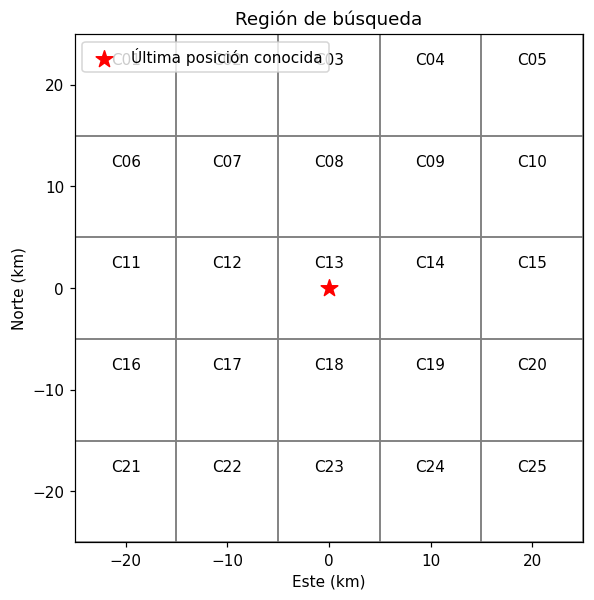

In [5]:
# Las coordenadas son centros de cuadrados de 10 km de lado.

fig, ax = plt.subplots(figsize=(6, 6))
for row in cells.itertuples():
    ax.add_patch(
        Rectangle((row.x_km - 5, row.y_km - 5), 10, 10, fill=False, edgecolor="gray")
    )
    ax.text(row.x_km, row.y_km + 2, row.cell_id, ha="center")
ax.scatter(0, 0, marker="*", s=130, color="red", label="Última posición conocida")
ax.set(
    xlim=(-25, 25),
    ylim=(-25, 25),
    aspect="equal",
    xlabel="Este (km)",
    ylabel="Norte (km)",
    title="Región de búsqueda",
)
ax.legend(loc="upper left")
plt.show()

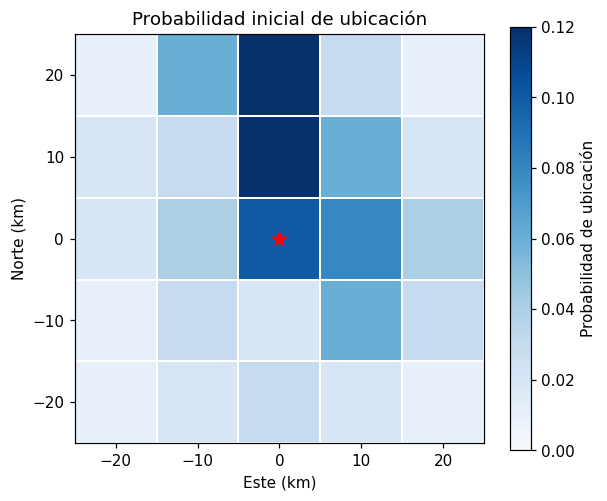

In [6]:
# ¿Qué zonas parecen más plausibles antes de decidir dónde buscar?

edges = np.arange(-25, 26, 10)
prior_grid = cells.pivot(
    index="y_km", columns="x_km", values="prior_probability"
).sort_index()
fig, ax = plt.subplots(figsize=(6, 5))
mesh = ax.pcolormesh(
    edges,
    edges,
    prior_grid,
    cmap="Blues",
    vmin=0,
    vmax=cells.prior_probability.max(),
    edgecolors="white",
)
ax.scatter(0, 0, marker="*", color="red", s=90)
ax.set(
    aspect="equal",
    xlabel="Este (km)",
    ylabel="Norte (km)",
    title="Probabilidad inicial de ubicación",
)
fig.colorbar(mesh, ax=ax, label="Probabilidad de ubicación")
plt.show()

In [7]:
# Estrategia intuitiva: comenzar cerca del origen; desempatar por cell_id.

cells["distance_km"] = np.hypot(cells.x_km, cells.y_km)
naive_order = cells.sort_values(["distance_km", "cell_id"]).copy()
naive_order["naive_priority"] = np.arange(1, len(cells) + 1)
display(naive_order[["cell_id", "distance_km", "naive_priority"]])

,cell_id,distance_km,naive_priority
12,C13,0.000000,1
7,C08,10.000000,2
11,C12,10.000000,3
13,C14,10.000000,4
17,C18,10.000000,5
6,C07,14.142136,6
8,C09,14.142136,7
16,C17,14.142136,8
18,C19,14.142136,9
2,C03,20.000000,10


['C13', 'C08', 'C12', 'C14', 'C18', 'C07']

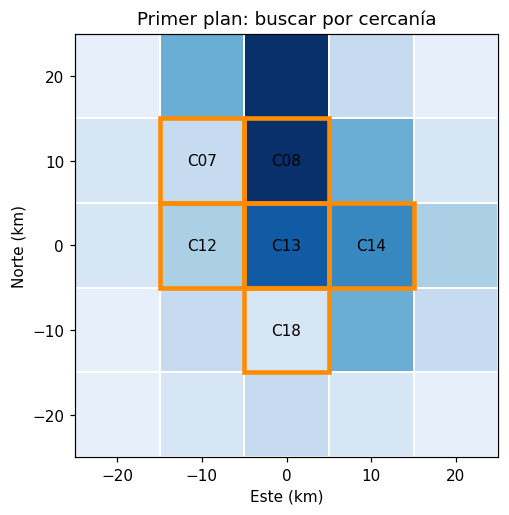

In [8]:
# El presupuesto deja zonas sin explorar.

naive_ids = naive_order.head(budget1).cell_id.tolist()
fig, ax = plt.subplots(figsize=(6, 5))
ax.pcolormesh(
    edges,
    edges,
    prior_grid,
    cmap="Blues",
    vmin=0,
    vmax=cells.prior_probability.max(),
    edgecolors="white",
)
for row in cells[cells.cell_id.isin(naive_ids)].itertuples():
    ax.add_patch(
        Rectangle(
            (row.x_km - 5, row.y_km - 5),
            10,
            10,
            fill=False,
            edgecolor="darkorange",
            linewidth=3,
        )
    )
    ax.text(row.x_km, row.y_km, row.cell_id, ha="center", va="center")
ax.set(
    aspect="equal",
    xlabel="Este (km)",
    ylabel="Norte (km)",
    title="Primer plan: buscar por cercanía",
)
display(naive_ids)
plt.show()

In [9]:
# Cubrir una ubicación posible todavía no garantiza detectar el avión.

naive_coverage = cells.loc[cells.cell_id.isin(naive_ids), "prior_probability"].sum()
display(
    pd.Series({"unidades": len(naive_ids), "probabilidad_cubierta": naive_coverage})
)

unidades                 6.00
probabilidad_cubierta    0.39
dtype: float64

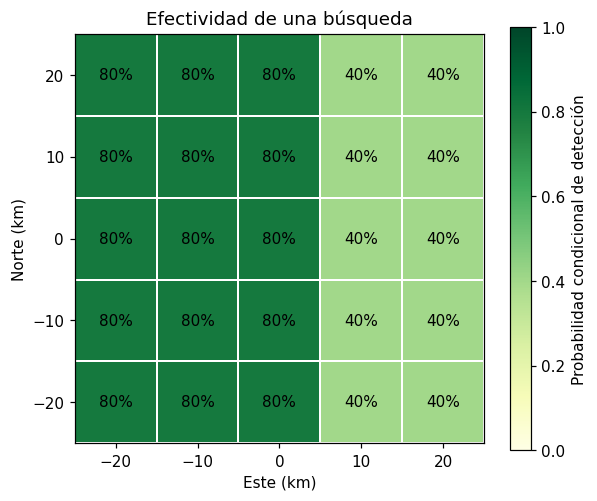

In [10]:
# Efectividad: detectar SI el avión está en la celda y la buscamos.

detection_grid = cells.pivot(
    index="y_km", columns="x_km", values="detection_probability"
).sort_index()
fig, ax = plt.subplots(figsize=(6, 5))
mesh = ax.pcolormesh(
    edges, edges, detection_grid, cmap="YlGn", vmin=0, vmax=1, edgecolors="white"
)
for row in cells.itertuples():
    ax.text(
        row.x_km, row.y_km, f"{row.detection_probability:.0%}", ha="center", va="center"
    )
ax.set(
    aspect="equal",
    xlabel="Este (km)",
    ylabel="Norte (km)",
    title="Efectividad de una búsqueda",
)
fig.colorbar(mesh, ax=ax, label="Probabilidad condicional de detección")
plt.show()

In [11]:
# Éxito = probabilidad de ubicación × efectividad de detección.

cells["success_probability"] = cells.prior_probability * cells.detection_probability
display(
    cells.loc[
        cells.cell_id.isin(["C09", "C12"]),
        [
            "cell_id",
            "prior_probability",
            "detection_probability",
            "success_probability",
        ],
    ]
)

,cell_id,prior_probability,detection_probability,success_probability
8,C09,0.06,0.4,0.024
11,C12,0.04,0.8,0.032


In [12]:
# Sumamos éxitos porque el avión ocupa una sola celda.

naive_success = cells.loc[cells.cell_id.isin(naive_ids), "success_probability"].sum()
display(
    pd.Series(
        {"probabilidad_cubierta": naive_coverage, "probabilidad_exito": naive_success}
    )
)

probabilidad_cubierta    0.39
probabilidad_exito       0.28
dtype: float64

In [13]:
# Con costos iguales, interesa el aporte al éxito de cada búsqueda.
# Redondeamos solo la clave de orden para respetar empates matemáticos.

location_order = cells.sort_values(
    ["prior_probability", "cell_id"], ascending=[False, True]
)
success_order = cells.assign(
    priority_score=cells.success_probability.round(12)
).sort_values(["priority_score", "cell_id"], ascending=[False, True])
display(
    pd.DataFrame(
        {
            "por_ubicacion": location_order.head(budget1).cell_id.to_numpy(),
            "por_exito": success_order.head(budget1).cell_id.to_numpy(),
        }
    )
)

,por_ubicacion,por_exito
0,C03,C03
1,C08,C08
2,C13,C13
3,C14,C02
4,C02,C12
5,C09,C14


In [14]:
# Una acción por celda y costos iguales: ordenar y seleccionar seis.
round1 = success_order.copy()
round1["priority_rank"] = np.arange(1, len(cells) + 1)
round1["allocated_units"] = (round1.priority_rank <= budget1).astype(int)
first_ids = round1.loc[round1.allocated_units == 1, "cell_id"].tolist()
display(
    round1.head(budget1)[
        [
            "cell_id",
            "prior_probability",
            "success_probability",
            "priority_rank",
            "allocated_units",
        ]
    ]
)

,cell_id,prior_probability,success_probability,priority_rank,allocated_units
2,C03,0.12,0.096,1,1
7,C08,0.12,0.096,2,1
12,C13,0.10,0.080,3,1
1,C02,0.06,0.048,4,1
11,C12,0.04,0.032,5,1
13,C14,0.08,0.032,6,1


In [15]:
# Comparación con idéntica capacidad; cobertura y éxito son métricas distintas.

first_coverage = round1.loc[round1.allocated_units == 1, "prior_probability"].sum()
first_success = round1.loc[round1.allocated_units == 1, "success_probability"].sum()
comparison1 = pd.DataFrame(
    [
        [1, "naive_distance", budget1, len(naive_ids), naive_coverage, naive_success],
        [
            1,
            "recommended_initial",
            budget1,
            len(first_ids),
            first_coverage,
            first_success,
        ],
    ],
    columns=[
        "round_id",
        "strategy",
        "budget_units",
        "used_units",
        "covered_probability",
        "success_probability",
    ],
)
display(comparison1)
print(
    f"Mejora en éxito: {100 * (first_success - naive_success):.1f} puntos porcentuales"
)

,round_id,strategy,budget_units,used_units,covered_probability,success_probability
0,1,naive_distance,6,6,0.39,0.280
1,1,recommended_initial,6,6,0.52,0.384


Mejora en éxito: 10.4 puntos porcentuales


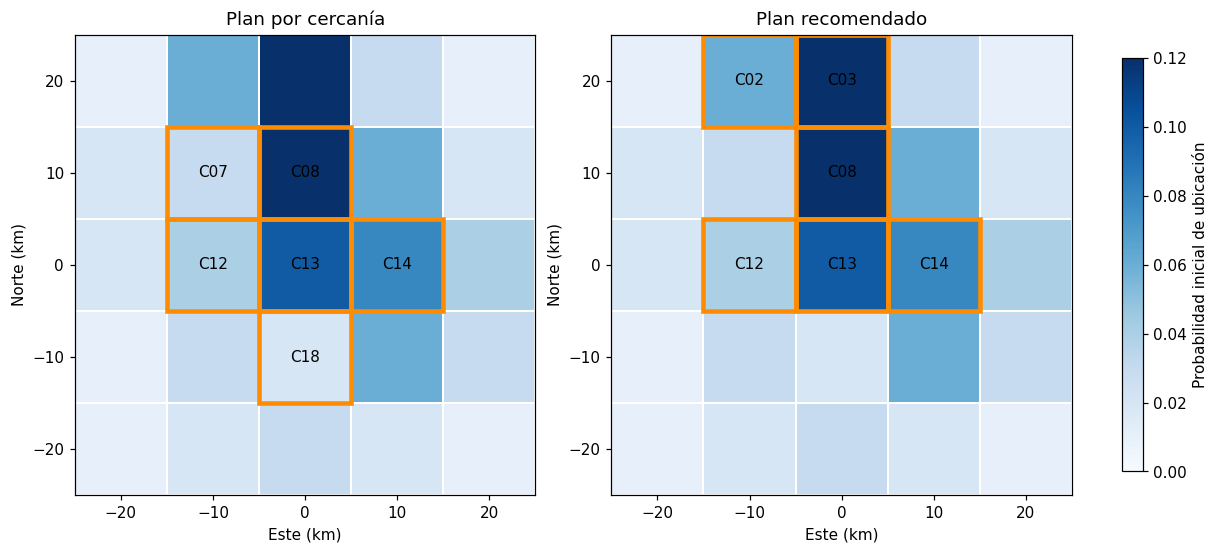

In [16]:
# La reasignación hacia el norte responde a probabilidad y detectabilidad.

fig, axes = plt.subplots(1, 2, figsize=(11, 5), layout="constrained")
for ax, ids, title in zip(
    axes, [naive_ids, first_ids], ["Plan por cercanía", "Plan recomendado"]
):
    mesh = ax.pcolormesh(
        edges,
        edges,
        prior_grid,
        cmap="Blues",
        vmin=0,
        vmax=cells.prior_probability.max(),
        edgecolors="white",
    )
    for row in cells[cells.cell_id.isin(ids)].itertuples():
        ax.add_patch(
            Rectangle(
                (row.x_km - 5, row.y_km - 5),
                10,
                10,
                fill=False,
                edgecolor="darkorange",
                linewidth=3,
            )
        )
        ax.text(row.x_km, row.y_km, row.cell_id, ha="center", va="center")
    ax.set(aspect="equal", xlabel="Este (km)", ylabel="Norte (km)", title=title)
fig.colorbar(mesh, ax=axes, label="Probabilidad inicial de ubicación", shrink=0.8)
plt.show()

In [17]:
# Solo la búsqueda recomendada se ejecutó; la comparación ingenua no aporta evidencia.

outcome1 = rounds.loc[1, "search_outcome"]
assert outcome1 == "unsuccessful"
cells["searched_round1"] = cells.cell_id.isin(first_ids)
display(
    outcome1, cells.loc[cells.searched_round1, ["cell_id", "detection_probability"]]
)

'unsuccessful'

,cell_id,detection_probability
1,C02,0.8
2,C03,0.8
7,C08,0.8
11,C12,0.8
12,C13,0.8
13,C14,0.4


In [18]:
# Retenemos la fracción que pudo pasar inadvertida; aún son pesos sin normalizar.
cells["remaining_weight"] = cells.prior_probability * np.where(
    cells.searched_round1, 1 - cells.detection_probability, 1
)
display(
    cells.loc[
        cells.cell_id.isin(["C03", "C14", "C09"]),
        ["cell_id", "searched_round1", "prior_probability", "remaining_weight"],
    ]
)

,cell_id,searched_round1,prior_probability,remaining_weight
2,C03,True,0.12,0.024
8,C09,False,0.06,0.060
13,C14,True,0.08,0.048


In [19]:
# Las zonas no buscadas ganan probabilidad relativa al normalizar.

remaining_total = cells.remaining_weight.sum()
assert remaining_total > 0
cells["updated_probability"] = cells.remaining_weight / remaining_total
display(
    pd.Series(
        {
            "peso_restante": remaining_total,
            "suma_actualizada": cells.updated_probability.sum(),
        }
    )
)
display(cells[["cell_id", "prior_probability", "updated_probability"]])

peso_restante       0.616
suma_actualizada    1.000
dtype: float64

,cell_id,prior_probability,updated_probability
0,C01,0.01,0.016234
1,C02,0.06,0.019481
2,C03,0.12,0.038961
3,C04,0.03,0.048701
4,C05,0.01,0.016234
5,C06,0.02,0.032468
6,C07,0.03,0.048701
7,C08,0.12,0.038961
8,C09,0.06,0.097403
9,C10,0.02,0.032468


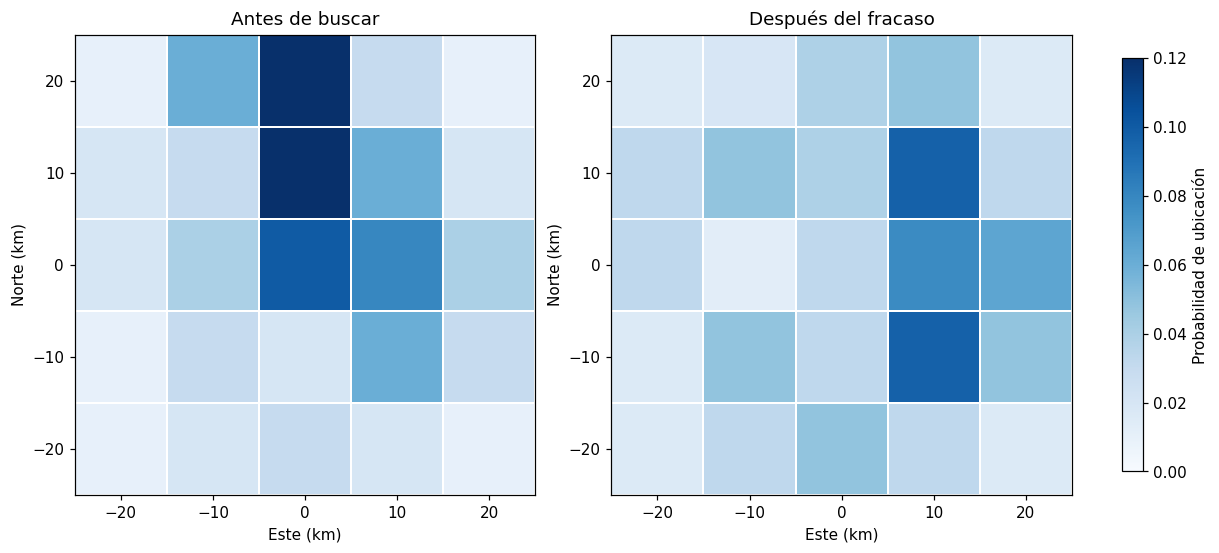

In [20]:
# No encontrar reduce plausibilidad, sin descartar automáticamente una celda.

updated_grid = cells.pivot(
    index="y_km", columns="x_km", values="updated_probability"
).sort_index()
probability_max = max(cells.prior_probability.max(), cells.updated_probability.max())
fig, axes = plt.subplots(1, 2, figsize=(11, 5), layout="constrained")
for ax, grid, title in zip(
    axes, [prior_grid, updated_grid], ["Antes de buscar", "Después del fracaso"]
):
    mesh = ax.pcolormesh(
        edges,
        edges,
        grid,
        cmap="Blues",
        vmin=0,
        vmax=probability_max,
        edgecolors="white",
    )
    ax.set(aspect="equal", xlabel="Este (km)", ylabel="Norte (km)", title=title)
fig.colorbar(mesh, ax=axes, label="Probabilidad de ubicación", shrink=0.8)
plt.show()

In [21]:
# Suponemos la misma efectividad en una nueva búsqueda, incluso tras un fracaso previo.

cells["updated_success_probability"] = (
    cells.updated_probability * cells.detection_probability
)
round2 = (
    cells.assign(priority_score=cells.updated_success_probability.round(12))
    .sort_values(["priority_score", "cell_id"], ascending=[False, True])
    .copy()
)
round2["priority_rank"] = np.arange(1, len(cells) + 1)
round2["allocated_units"] = (round2.priority_rank <= budget2).astype(int)
second_ids = round2.loc[round2.allocated_units == 1, "cell_id"].tolist()
display(
    round2.head(budget2)[
        [
            "cell_id",
            "updated_probability",
            "updated_success_probability",
            "priority_rank",
        ]
    ]
)

,cell_id,updated_probability,updated_success_probability,priority_rank
6,C07,0.048701,0.038961,1
8,C09,0.097403,0.038961,2
16,C17,0.048701,0.038961,3
18,C19,0.097403,0.038961,4
22,C23,0.048701,0.038961,5
2,C03,0.038961,0.031169,6


In [22]:
# El fracaso puede justificar explorar otras zonas y repetir algunas búsquedas.
display(
    pd.Series(
        {
            "entran": sorted(set(second_ids) - set(first_ids)),
            "salen": sorted(set(first_ids) - set(second_ids)),
            "permanecen": sorted(set(first_ids) & set(second_ids)),
        }
    )
)

entran        [C07, C09, C17, C19, C23]
salen         [C02, C08, C12, C13, C14]
permanecen                        [C03]
dtype: object

In [23]:
# Ambas alternativas se evalúan con la MISMA información posterior al fracaso.
# Estas probabilidades de éxito son condicionales a no haber encontrado antes.

repeat = cells[cells.cell_id.isin(first_ids)]
revised = cells[cells.cell_id.isin(second_ids)]
comparison2 = pd.DataFrame(
    [
        [
            2,
            "repeat_initial",
            budget2,
            len(repeat),
            repeat.updated_probability.sum(),
            repeat.updated_success_probability.sum(),
        ],
        [
            2,
            "recommended_revised",
            budget2,
            len(revised),
            revised.updated_probability.sum(),
            revised.updated_success_probability.sum(),
        ],
    ],
    columns=comparison1.columns,
)
display(comparison2)

,round_id,strategy,budget_units,used_units,covered_probability,success_probability
0,2,repeat_initial,6,6,0.220779,0.145455
1,2,recommended_revised,6,6,0.379870,0.225974


In [24]:
# La segunda ronda es una recomendación pendiente de ejecución.

assert rounds.loc[2, "search_outcome"] == "not_executed"
plan_comparison = pd.concat([comparison1, comparison2], ignore_index=True)
display(plan_comparison)

,round_id,strategy,budget_units,used_units,covered_probability,success_probability
0,1,naive_distance,6,6,0.390000,0.280000
1,1,recommended_initial,6,6,0.520000,0.384000
2,2,repeat_initial,6,6,0.220779,0.145455
3,2,recommended_revised,6,6,0.379870,0.225974


In [25]:
# Cada fila conserva la información disponible al inicio de su ronda.

plan1 = round1.rename(columns={"prior_probability": "location_probability"}).assign(
    round_id=1, searched_previous_round=0
)
plan2 = round2.rename(
    columns={
        "updated_probability": "location_probability",
        "success_probability": "initial_success_probability",
        "updated_success_probability": "success_probability",
    }
).assign(round_id=2)
plan2["searched_previous_round"] = plan2.searched_round1.astype(int)
plan_columns = [
    "round_id",
    "cell_id",
    "location_probability",
    "detection_probability",
    "success_probability",
    "priority_rank",
    "allocated_units",
    "searched_previous_round",
]
search_plan = pd.concat(
    [plan1[plan_columns], plan2[plan_columns]], ignore_index=True
).sort_values(["round_id", "cell_id"])
display(search_plan.head(), search_plan.shape)

,round_id,cell_id,location_probability,detection_probability,success_probability,priority_rank,allocated_units,searched_previous_round
18,1,C01,0.01,0.8,0.008,19,0,0
3,1,C02,0.06,0.8,0.048,4,1,0
0,1,C03,0.12,0.8,0.096,1,1,0
16,1,C04,0.03,0.4,0.012,17,0,0
23,1,C05,0.01,0.4,0.004,24,0,0


(50, 8)

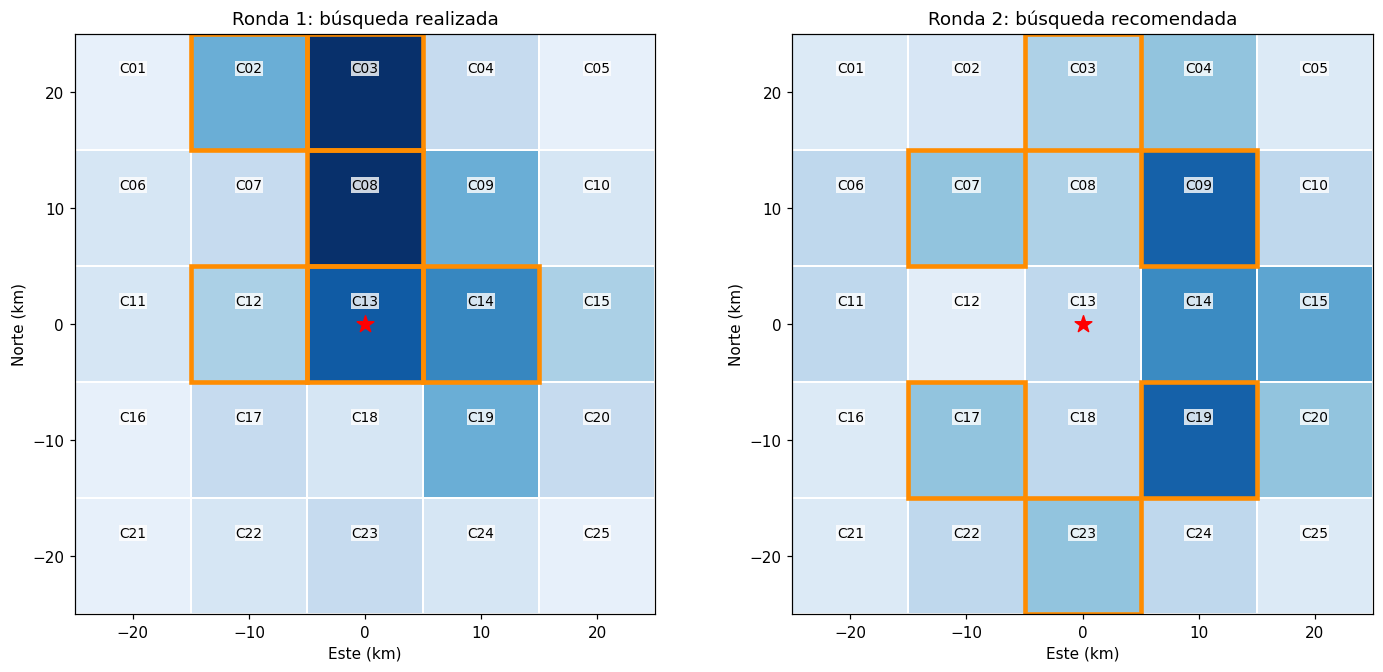

In [26]:
# El mapa reúne creencias espaciales y las dos asignaciones.

planning_fig, planning_axes = plt.subplots(1, 2, figsize=(13, 6), layout="constrained")
for ax, grid, ids, title in zip(
    planning_axes,
    [prior_grid, updated_grid],
    [first_ids, second_ids],
    ["Ronda 1: búsqueda realizada", "Ronda 2: búsqueda recomendada"],
):
    planning_mesh = ax.pcolormesh(
        edges,
        edges,
        grid,
        cmap="Blues",
        vmin=0,
        vmax=probability_max,
        edgecolors="white",
    )
    for row in cells.itertuples():
        ax.text(
            row.x_km,
            row.y_km + 2,
            row.cell_id,
            ha="center",
            va="center",
            fontsize=9,
            color="black",
            bbox={"facecolor": "white", "alpha": 0.8, "edgecolor": "none", "pad": 0.5},
        )
        if row.cell_id in ids:
            ax.add_patch(
                Rectangle(
                    (row.x_km - 5, row.y_km - 5),
                    10,
                    10,
                    fill=False,
                    edgecolor="darkorange",
                    linewidth=3,
                )
            )
    ax.scatter(
        0, 0, marker="*", s=130, color="red", zorder=5, label="Última posición conocida"
    )
    ax.set(
        aspect="equal",
        xlabel="Este (km)",
        ylabel="Norte (km)",
        title=title,
        xticks=np.arange(-20, 21, 10),
        yticks=np.arange(-20, 21, 10),
    )
plt.show()

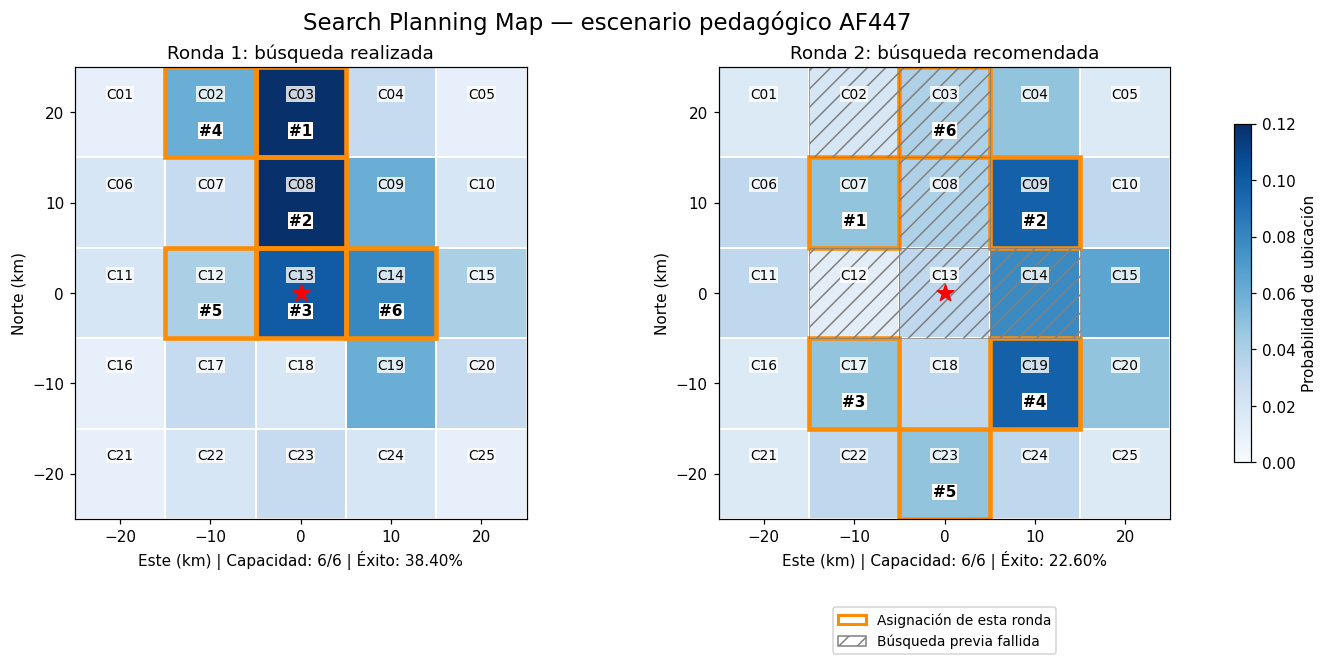

In [27]:
# Contornos: asignación; trama: búsqueda anterior fallida; números: orden recomendado.

for row in cells[cells.searched_round1].itertuples():
    planning_axes[1].add_patch(
        Rectangle(
            (row.x_km - 5, row.y_km - 5),
            10,
            10,
            fill=False,
            hatch="//",
            edgecolor="gray",
            linewidth=0.5,
        )
    )
for ax, ids, success, budget in zip(
    planning_axes,
    [first_ids, second_ids],
    [first_success, revised.updated_success_probability.sum()],
    [budget1, budget2],
):
    for priority, cell_id in enumerate(ids, 1):
        row = cells.set_index("cell_id").loc[cell_id]
        ax.text(
            row.x_km,
            row.y_km - 2,
            f"#{priority}",
            ha="center",
            va="center",
            weight="bold",
            bbox={"facecolor": "white", "edgecolor": "none", "pad": 0.5},
        )
    ax.set_xlabel(f"Este (km) | Capacidad: {len(ids)}/{budget} | Éxito: {success:.2%}")
planning_fig.colorbar(
    planning_mesh, ax=planning_axes, label="Probabilidad de ubicación", shrink=0.75
)
planning_fig.suptitle("Search Planning Map — escenario pedagógico AF447", fontsize=15)
planning_axes[1].legend(
    handles=[
        Patch(
            facecolor="none",
            edgecolor="darkorange",
            linewidth=2,
            label="Asignación de esta ronda",
        ),
        Patch(
            facecolor="none",
            edgecolor="gray",
            hatch="//",
            label="Búsqueda previa fallida",
        ),
    ],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    fontsize=9,
)
display(planning_fig)

In [28]:
# Verificamos restricciones y resultados antes de entregar el plan.

assert (
    len(search_plan) == 50 and not search_plan.duplicated(["round_id", "cell_id"]).any()
)
assert np.allclose(search_plan.groupby("round_id").location_probability.sum(), 1)
assert search_plan.allocated_units.isin([0, 1]).all()
assert search_plan.groupby("round_id").allocated_units.sum().tolist() == [
    budget1,
    budget2,
]
assert np.allclose(
    search_plan.success_probability,
    search_plan.location_probability * search_plan.detection_probability,
)
assert naive_ids == ["C13", "C08", "C12", "C14", "C18", "C07"]
assert first_ids == ["C03", "C08", "C13", "C02", "C12", "C14"]
assert second_ids == ["C07", "C09", "C17", "C19", "C23", "C03"]
assert np.allclose(
    [naive_coverage, naive_success, first_coverage, first_success],
    [0.39, 0.28, 0.52, 0.384],
)
assert np.isclose(remaining_total, 1 - first_success)
for round_id, strategy in [(1, "recommended_initial"), (2, "recommended_revised")]:
    selected = search_plan[
        (search_plan.round_id == round_id) & (search_plan.allocated_units == 1)
    ]
    metrics = plan_comparison[plan_comparison.strategy == strategy].iloc[0]
    assert np.allclose(
        [selected.location_probability.sum(), selected.success_probability.sum()],
        [metrics.covered_probability, metrics.success_probability],
    )
print(
    "Plan consistente: 50 registros, seis búsquedas por ronda y decisiones aprobadas."
)

Plan consistente: 50 registros, seis búsquedas por ronda y decisiones aprobadas.


In [29]:
# Información → acción → fracaso observado → reasignación reproducible.
submission_dir.mkdir(exist_ok=True)
search_plan.to_csv(submission_dir / "search_plan.csv", index=False)
plan_comparison.to_csv(submission_dir / "plan_comparison.csv", index=False)
planning_fig.savefig(
    submission_dir / "search_planning_map.png",
    dpi=180,
    bbox_inches="tight",
    facecolor="white",
)
display(
    [
        str(submission_dir / name)
        for name in [
            "search_plan.csv",
            "plan_comparison.csv",
            "search_planning_map.png",
        ]
    ]
)

['../submission/search_plan.csv',
 '../submission/plan_comparison.csv',
 '../submission/search_planning_map.png']